<a href="https://colab.research.google.com/github/KellyData23/Predictive-Modeling-for-Heart-Disease-Diagnosis/blob/main/Prediction_Modeling_for_Heart_Disease_Diagnosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Prediction Modeling for Heart Disease Diagnosis**

####WQD 7003 Data Analytics

# **1. Business Understanding**

### 1.1 Project Overview

###1.2 Objectives


*   To develop machine learning-based predictive models for heart disease detection based on the medical parameters identified.
*   To evaluate and compare the performance of selected machine learning models based on the accuracy metrics.
*   To find the optimal machine learning algorithm to predict the presence or absence of heart disease based on the medical parameters.
* To build a data product to access users’ cardiovascular risk based on the optimal machine learning algorithm built


###1.3 Statement of Problem


#### 1.3.1 Current State of Heart Disease
* Heart disease remains a major global health concern despite advances in medical science (Abdollahi & Nouri-Moghaddam, 2022).
* We aim to get an awareness of the current situation, including the prevalence, risk factors, and challenges related to early identification that are specific to this population by using the "Heart Disease Dataset" and focusing on the subset of 14 attributes.


#### 1.3.2 Need for Predictive Modelling
* The set of 14 variables contains complicated patterns that conventional methods of diagnosing heart disease may not be able to manage, predictive modelling is required.
* A data-driven approach is required to uncover hidden relationships and produce precise prediction models appropriate for this group. This will help with early detection that is more successful and accurate.

#### 1.3.3 Consistency Between the Project and the Health Care Goal
* This study has contributed to broader health care goal by improving the patient's curative effect, reduced costs, and encouraging preventive care.

# **2. Data Pre-processing**

##**Attribute information:**
age

sex. It is integer valued 0 = female and 1 = male.

cp, chest pain type (4 values, level 0-3) 3 represent the highest pain, while 0 represent no pain detected.

trestbps, resting blood pressure

chol, serum cholestoral in mg/dl

fbs, fasting blood sugar > 120 mg/dl. It is integer valued 0 = Flase and 1 = True.

restecg, resting electrocardiographic results (values 0,1,2)

thalach, maximum heart rate achieved

exang, exercise induced angina. It is integer valued 0 = no exercise and 1 = exercise.

oldpeak = ST depression induced by exercise relative to rest

slope, the slope of the peak exercise ST segment

ca, number of major vessels (0-4) colored by flourosopy

thal: 0 = normal; 1 = fixed defect; 2 = reversable defect; 3= unknown

"target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.

Dataset source: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

In [ ]:
# install libraries
! pip install scikeras
! pip install matplotlib --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 20.2 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.1
    Uninstalling matplotlib-3.7.1:
      Successfully uninstalled matplotlib-3.7.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lida 0.0.10 requires fastapi, which is not installed.
lida 0.0.10 requires kaleido, which is not installed.
lida 0.0.10 requires python-multipart, which is not installed.
lida 0.0.10 requires uvicorn, which is not installed.


In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
# If directly from content file to read the dataset, the dataset will be disappear once disconnected
path = '/content/drive/MyDrive/UM Master of Data Science/WQD7003 Data Analytics/GROUP PROJECT/heart.csv'
df = pd.read_csv(path, delimiter=',')


Mounted at /content/drive


In [ ]:
# get the columns label
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
# view the first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# print a summary of the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


All datatypes are integer & float which is numerical datatype, hence, there is no categorical/objects datatypes in this data set.
This dataset consist of **14 columns** and **1025 records**.

In [ ]:
# round up all value to 2 decimal places
round(df.describe(),2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [ ]:
# detect missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In this dataset, there is no missing value detected.

In [ ]:
# detect duplicate rows
df.duplicated().sum()

723

723 duplicated rows are detected.

However, there definitely will have duplicate values in the heart disease symtoms. For example, it is possible to have same blood pressure, cholestrol and heart rate. Besides, some of the attributions are in binary value which is "0" and "1". Thus, no duplication data are removed from this dataset.

#**2.1 Exploratory Data Analysis (EDA)**


###2.1.1 Correlation matrix


Text(0.5, 1.0, 'Correlation Matrix for all features')

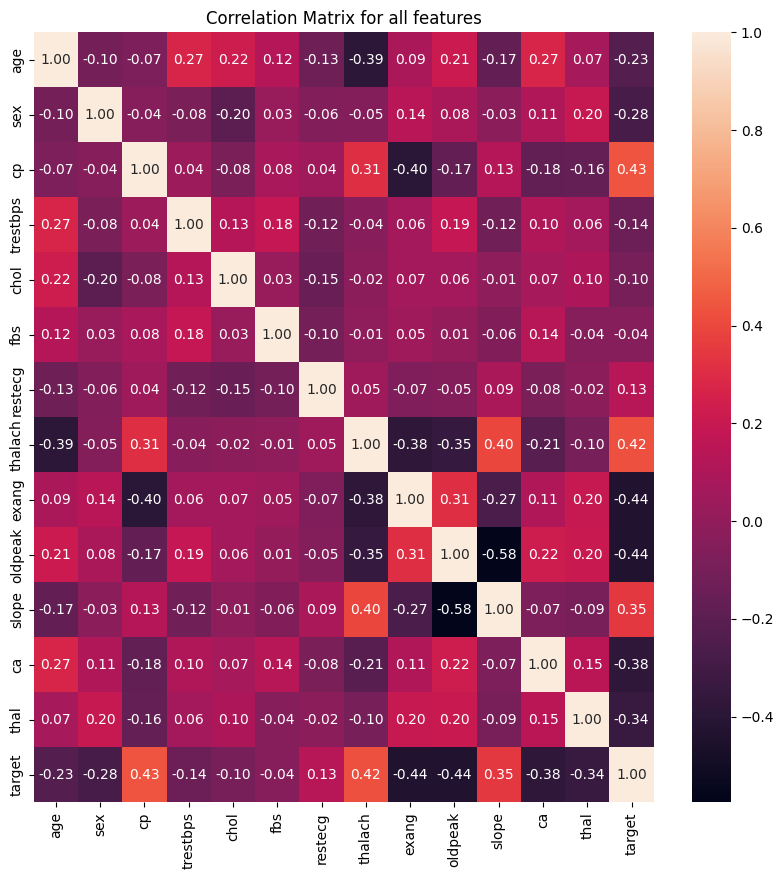

In [ ]:
corr=df.corr()
corr.style.background_gradient(cmap='coolwarm')
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,fmt='.2f')
plt.title('Correlation Matrix for all features')


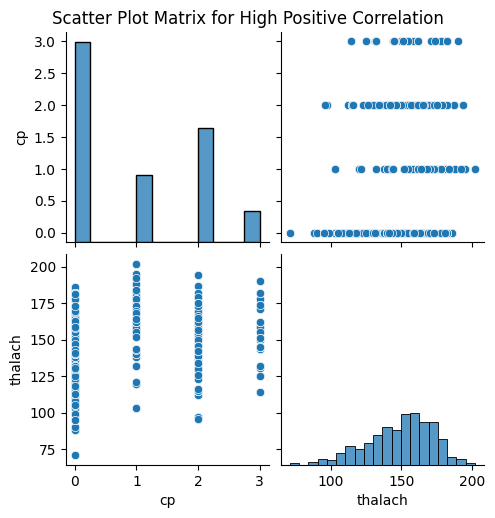

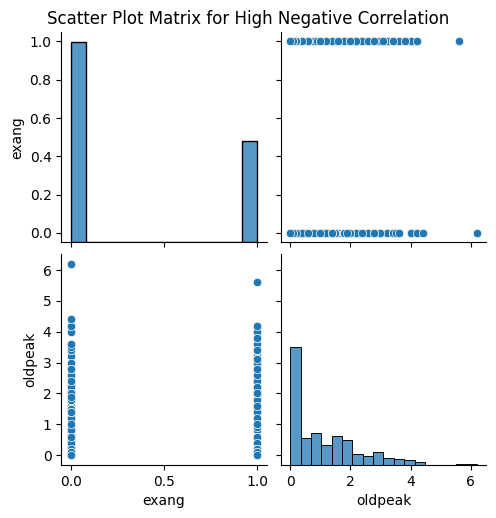

In [ ]:
# Features with high positive correlation against the target
high_positive_corr_vars = df[["cp", "thalach"]]

# Features with high negative correlation against the target
high_negative_corr_vars = df[["exang", "oldpeak"]]

# Create a scatter plot matrix for high positive correlation variables
sns.pairplot(high_positive_corr_vars)
plt.suptitle("Scatter Plot Matrix for High Positive Correlation",y=1.02)
plt.show()

# Create a scatter plot matrix for high negative correlation variables
sns.pairplot(high_negative_corr_vars)
plt.suptitle("Scatter Plot Matrix for High Negative Correlation",y=1.02)
plt.show()


From correlation matrix, target against chest pain (cp) and maximum heart rate (thalach) has highest positive correlation, while exercise induced angina (exang) and ST depression induced by exercise relative to rest (oldpeak) has present highest negative correlation.

In [ ]:
# Since there is no categorical datatype is detected, so the rest of the data is considered numerical and named as heart_data
# select the heart_data data column names & convert into list
heart_data = df.keys().tolist()
print('heart_data:', heart_data)

heart_data: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [ ]:
# visualize the distribution of heart_data
plt.figure(figsize=(15, 10))

for i, col in enumerate(heart_data):
    plt.subplot(int(np.ceil(len(heart_data) / 4)), 4, i+1)
    sns.kdeplot(data=df, x=col, fill=True)
    plt.title('Distribution of ' + str(heart_data[i].title()))
    plt.xlabel(str(heart_data[i].title()))
    plt.ylabel('Count of Observations')

plt.tight_layout()

plt.show()

NameError: name 'plt' is not defined

In [ ]:
# calculate the skewness of heart_data
for col in heart_data:
  skewness = 3 * (df[col].mean() - df[col].median()) / df[col].std()
  print(col, ':', skewness)

age : -0.5177921842046146
sex : -1.983543971522528
cp : -0.16771182365784573
trestbps : 0.27602898840613316
chol : 0.34888785073774436
fbs : 1.256020631699344
restecg : -2.672460047258305
thalach : -0.3763220436446209
exang : 2.1358187339461807
oldpeak : 0.693191207969339
slope : 1.8714491359389247
ca : 2.1948429853466425
thal : 1.5656026558499756
target : -2.920563821479235


From the distribution and skewness, we can know that:
*   Left/Negative skewed distributions including: sex, resting electrocardiographic
*   Right/Positive skewed distributions including: fasting blood sugar (fbs), slope of the peak exercise ST segment, ca, number of major vessels (0-4) colored by flourosopy.




## **Attribute Visualization**
Exploration of the relationship between each of the attributes and the target attribute will be showed in the form of visualization

###2.1.2 Heart Disease by Age

Text(0.5, 1.0, 'Heart disease by target')

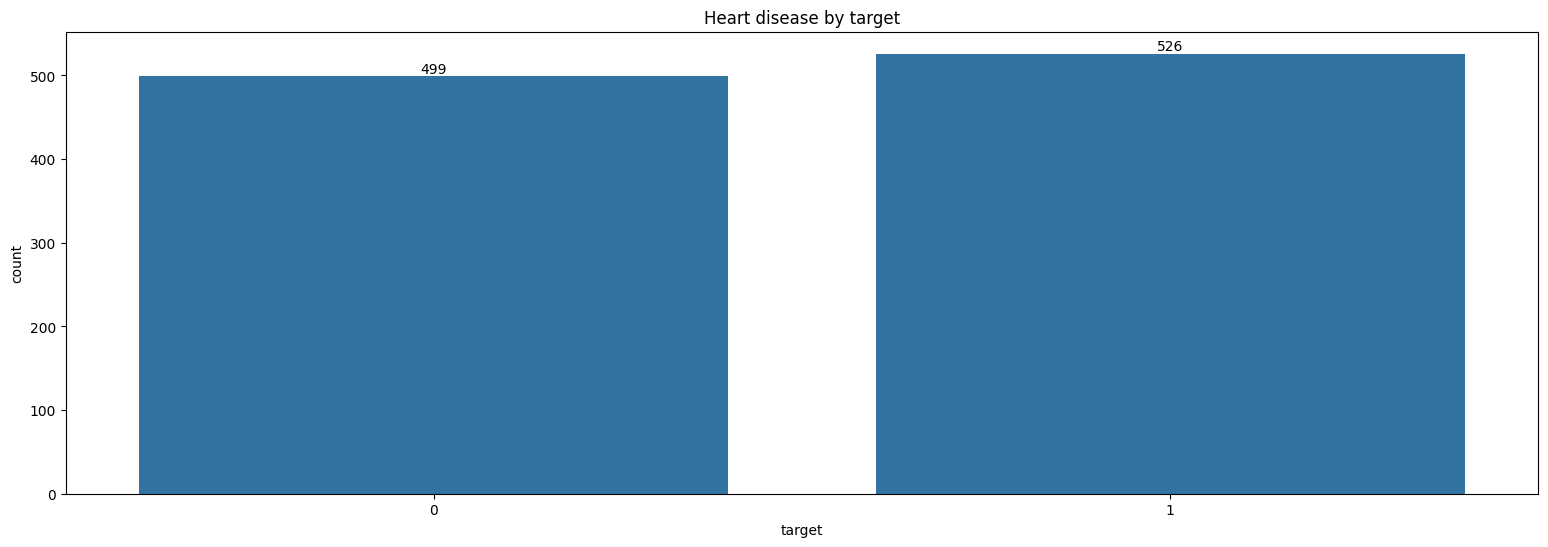

In [ ]:
fig, ax = plt.subplots(figsize=(19,6))
sns.countplot(data=df, x='target')
for i in ax.containers:
  ax.bar_label(i,)
ax.set_xlabel('target')
ax.set_ylabel('count')
ax.set_title('Heart disease by target')

Text(0.5, 1.0, 'Heart disease by Age')

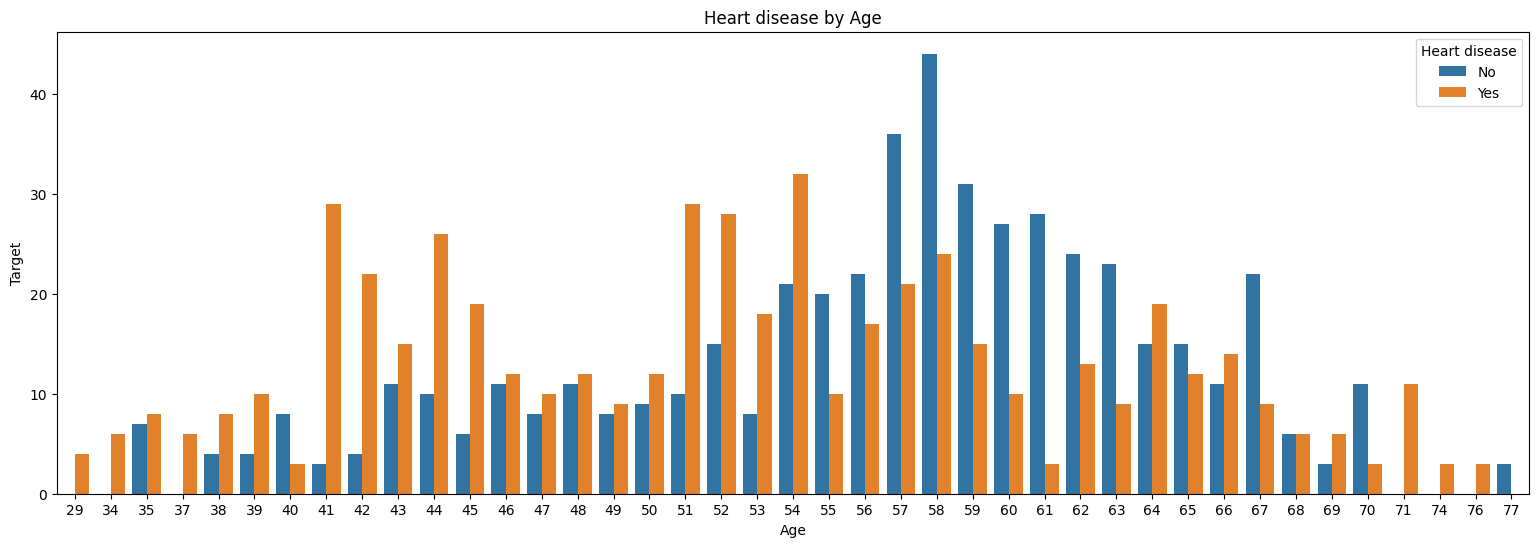

In [ ]:
#Plot the age against getting heart disease
fig, ax = plt.subplots(figsize=(19,6))
sns.countplot(data=df, x='age', hue='target')
ax.set_xlabel('Age')
ax.set_ylabel('Target')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Heart disease by Age')

In [ ]:
# convert ages to groups of age ranges
age_ranges = pd.cut(df['age'], bins=[0,19, 29, 39, 49, 59, 69, 79, 89, 99], labels=['0-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99'])

# insert age_ranges into df
df.insert(1, 'age_ranges', age_ranges)

In [ ]:
df.head(10)

,age,age_ranges,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,50-59,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,50-59,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,70-79,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,60-69,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,60-69,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,50-59,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,50-59,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,50-59,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,40-49,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,50-59,1,0,122,286,0,0,116,1,3.2,1,2,2,0


Text(0.5, 1.0, 'Heart disease by Age Ranges')

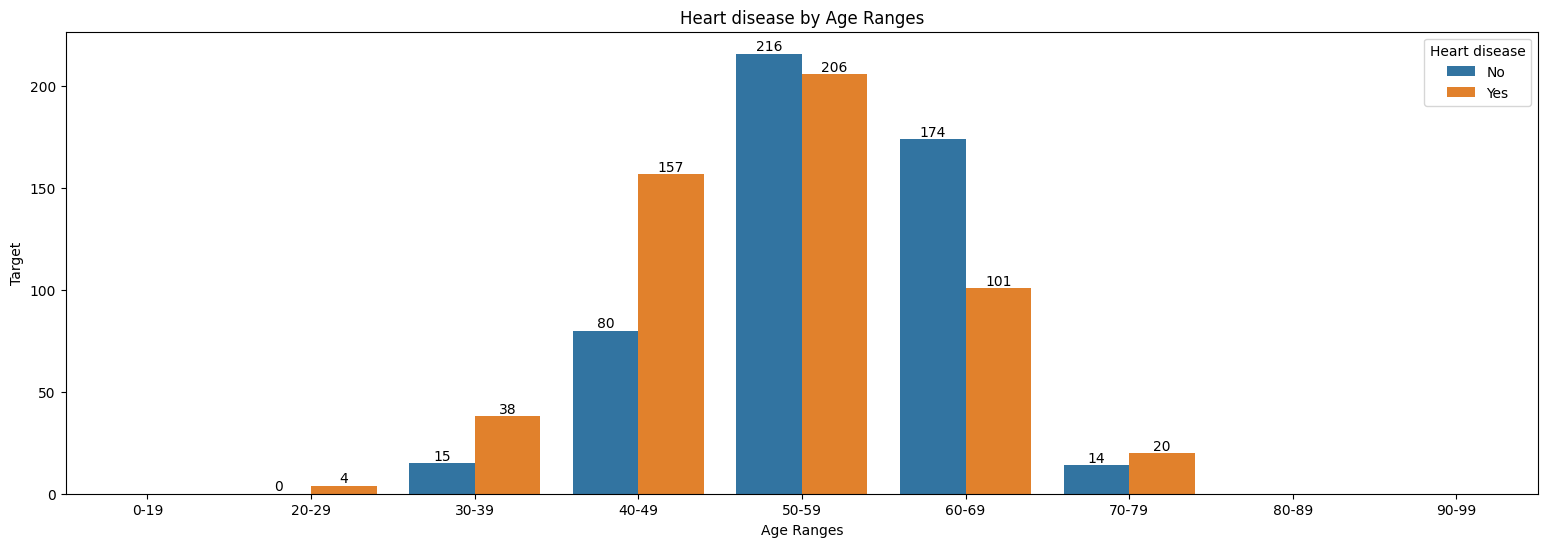

In [ ]:
fig, ax = plt.subplots(figsize=(19,6))
sns.countplot(data=df, x='age_ranges', hue='target')
for i in ax.containers:
  ax.bar_label(i,)
ax.set_xlabel('Age Ranges')
ax.set_ylabel('Target')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Heart disease by Age Ranges')

<ipython-input-19-b86e8a5c777f>:3: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  percentage_by_sex_age_50_59 = df_age_50_59.groupby(['sex', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100).unstack()


target          0          1
sex                         
0       32.110092  67.889908
1       57.827476  42.172524


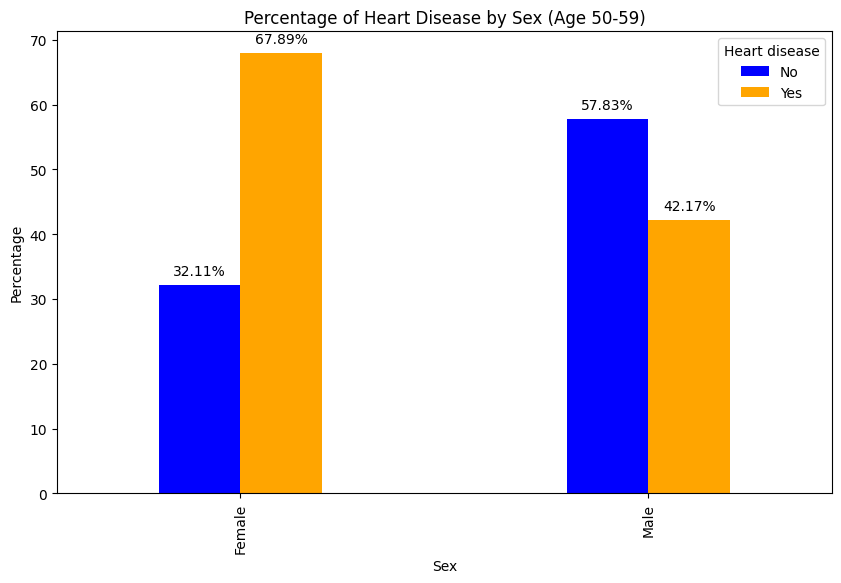

In [ ]:
#To understand how many heart disease percentage of male and female in age range of 50-59
df_age_50_59 = df[(df['age'] >= 50) & (df['age'] <= 59)]
percentage_by_sex_age_50_59 = df_age_50_59.groupby(['sex', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100).unstack()
print(percentage_by_sex_age_50_59)

fig, ax = plt.subplots(figsize=(10, 6))

percentage_by_sex_age_50_59.plot(kind='bar', ax=ax, color=['blue', 'orange'], width=0.4)
ax.set_xlabel('Sex')
ax.set_ylabel('Percentage')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Percentage of Heart Disease by Sex (Age 50-59)')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

From age range of 50-59 present highest chance of getting heart disease, while 20-29 present lowest chances. It might be due to age range of 20-29 is the teenagers range which possess the healthier heart condition compare to age range of 50-59.

From age range of 50-59, female present higher percentages of obtaining heart disease which is 67.89%, while male is less than 50%.

In [ ]:
df.head(10)
df.drop(columns=['age_ranges'], inplace=True)
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


### 2.1.3 Heart Disease by Sex

<ipython-input-21-e5fe8bf2ff28>:3: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  percentage_by_sex = df.groupby(['sex', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)


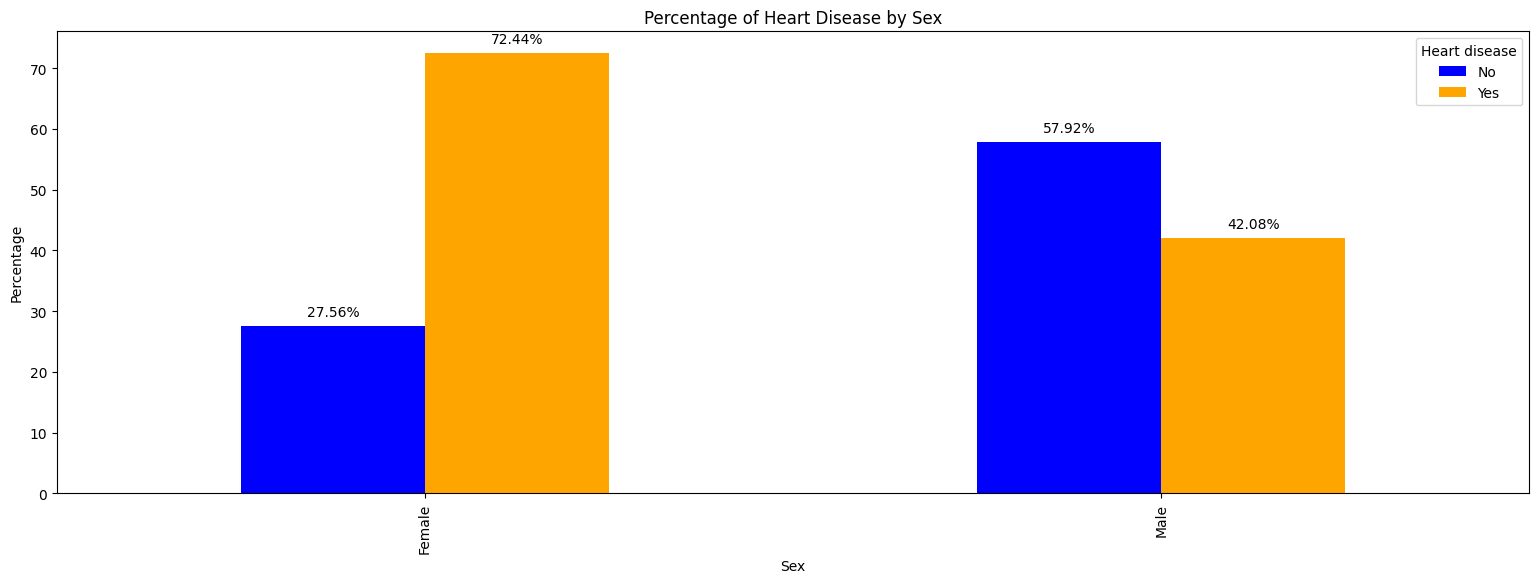

In [ ]:
# calculate the percentage of sex against getting heart disease
total_by_sex = df.groupby('sex')['target'].count()
percentage_by_sex = df.groupby(['sex', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)
percentage_by_sex = percentage_by_sex.unstack()

#Plot
fig, ax = plt.subplots(figsize=(19, 6))

percentage_by_sex.plot(kind='bar', ax=ax, color=['blue', 'orange'])
ax.set_xlabel('Sex')
ax.set_ylabel('Percentage')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Percentage of Heart Disease by Sex')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()


From the figure above, female has 72.44% of chances to get heart disease while male only 42.08%.
This result also same as the previous analysis from age range of 50-59.

###2.1.4 Heart Disease by Chest Pain

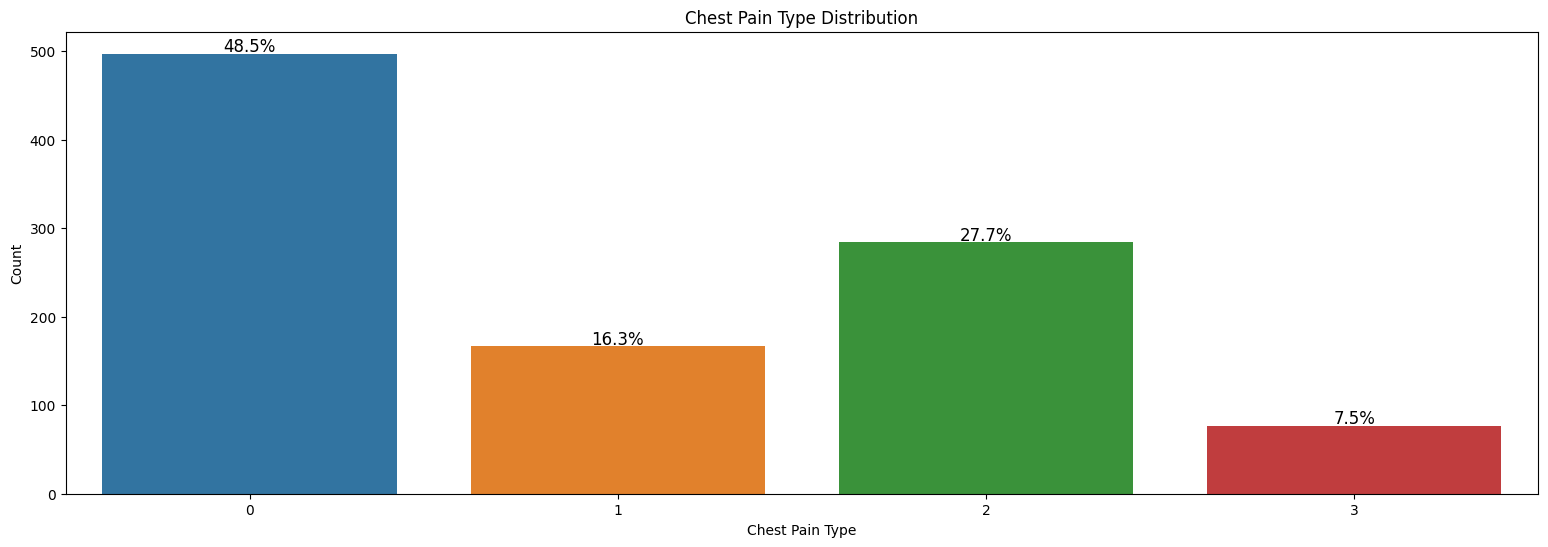

<ipython-input-22-24fd39d7c850>:19: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  percentage_by_cp = df.groupby(['cp', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)


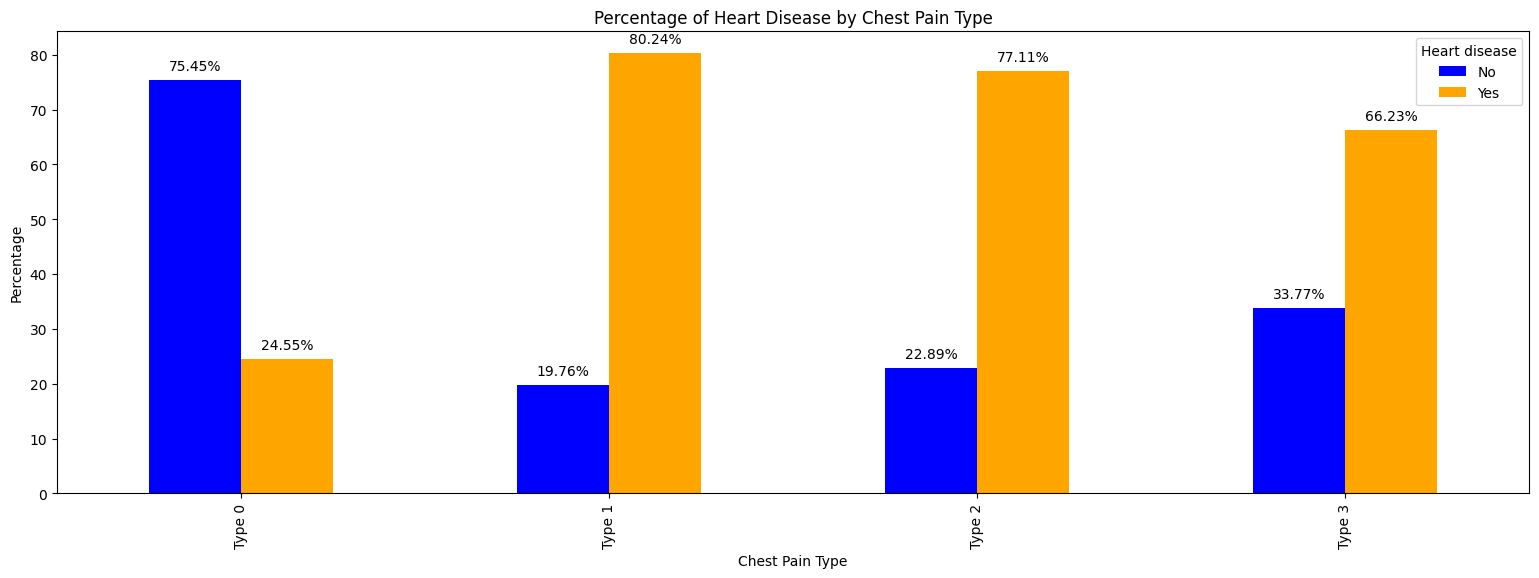

In [ ]:
# Chest Pain Type Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.countplot(x='cp', data=df, ax=ax)
ax.set_title('Chest Pain Type Distribution')
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Count')

# Adding percentage annotations
total = len(df['cp'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

total_by_cp = df.groupby('cp')['target'].count()
percentage_by_cp = df.groupby(['cp', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)
percentage_by_cp = percentage_by_cp.unstack()

# Plot
fig, ax = plt.subplots(figsize=(19, 6))

percentage_by_cp.plot(kind='bar', ax=ax, color=['blue', 'orange'])
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Percentage')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Percentage of Heart Disease by Chest Pain Type')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Type 0', 'Type 1', 'Type 2', 'Type 3'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()


There are 4 values to represented chest pain level, 3 represent the highest pain, while 0 represent no pain detected

The first bar chart displays the count of patients categorized by four levels of chest pain severity. The majority experience no chest pain, while a smaller number report the highest pain level. Percentages above the bars indicate the proportion within each category.

The second bar chart shows the percentage of patients with and without heart disease across different levels of chest pain severity. Notably, as chest pain severity increases, so does the proportion of patients with heart disease, underscoring a potential correlation between pain severity and heart disease presence.

###2.1.5 Heart Disease by Resting Blood Pressure


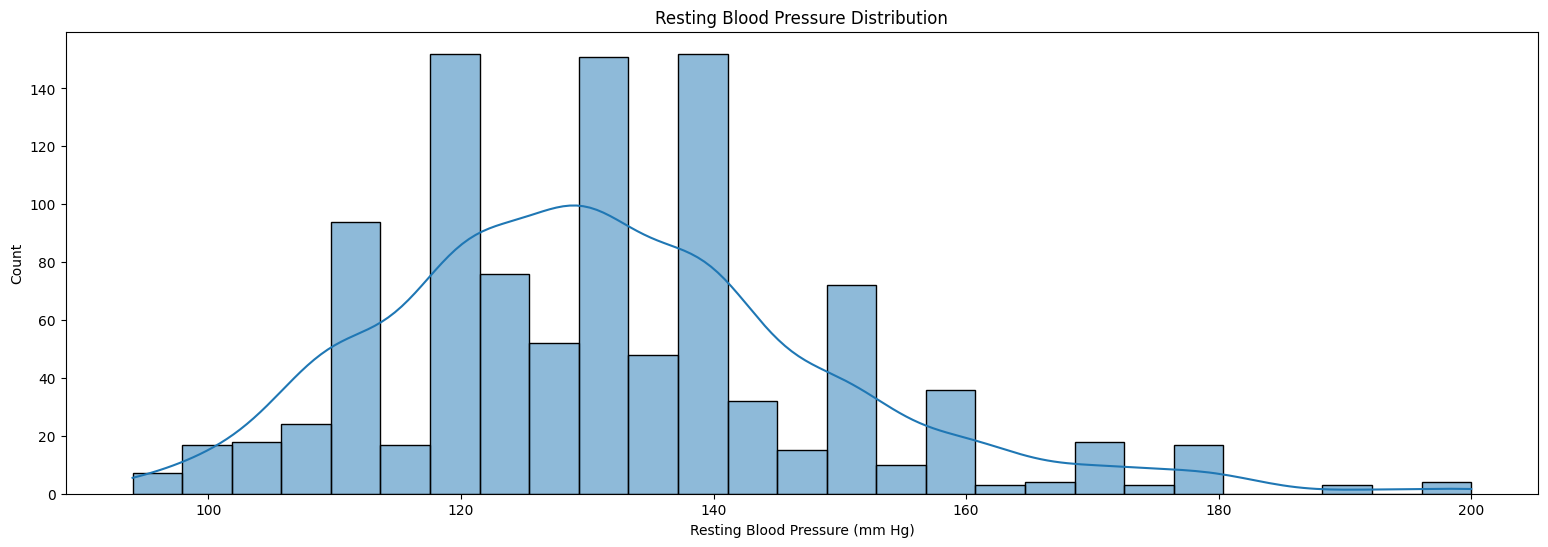

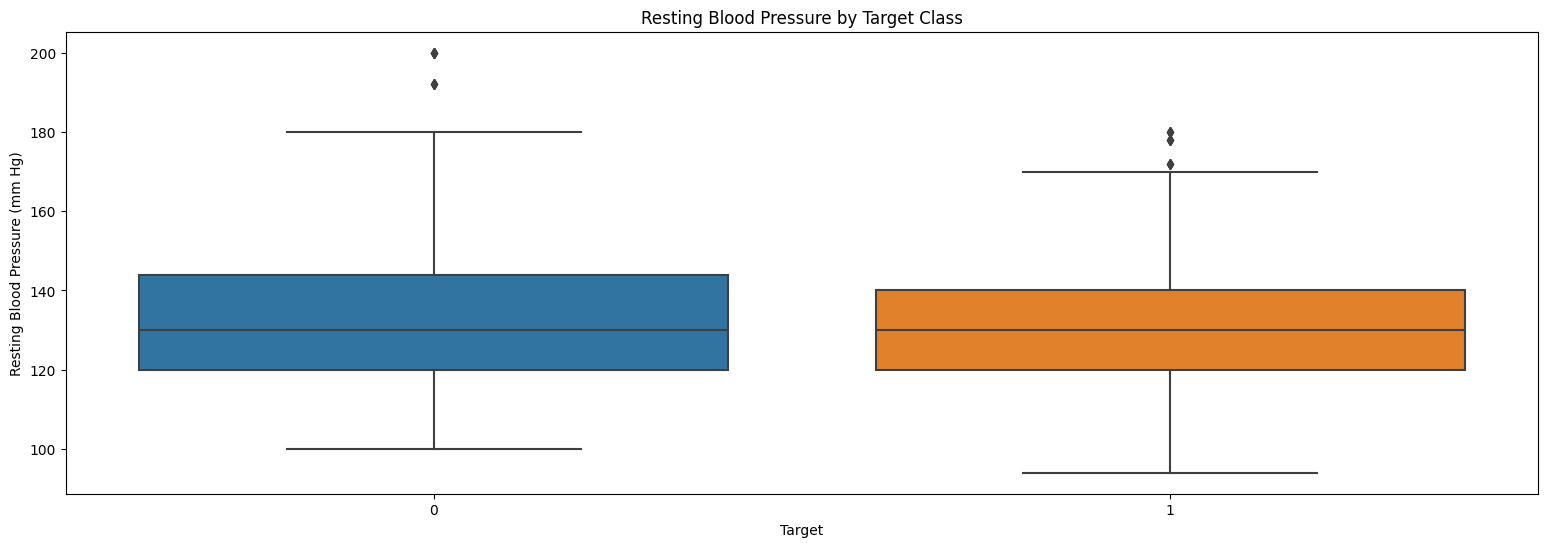

In [ ]:
# Resting Blood Pressure Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.histplot(df['trestbps'], kde=True, ax=ax)
ax.set_title('Resting Blood Pressure Distribution')
ax.set_xlabel('Resting Blood Pressure (mm Hg)')
ax.set_ylabel('Count')
plt.show()

fig, ax = plt.subplots(figsize=(19, 6))
sns.boxplot(x='target', y='trestbps', data=df, ax=ax)
ax.set_title('Resting Blood Pressure by Target Class')
ax.set_xlabel('Target')
ax.set_ylabel('Resting Blood Pressure (mm Hg)')
plt.show()




The histogram with a fitted density line shows the distribution of resting blood pressure across the patient cohort. Most patients have blood pressure readings clustered around the median range, with a few outliers on the higher end, indicating elevated blood pressure levels.The box plot illustrates the spread and median of resting blood pressure values among two groups: those without and with heart disease. Both groups show a wide range of blood pressure values, with outliers indicating particularly high blood pressure readings. Also,the median resting blood pressure appears slightly higher in the heart disease group.

###2.1.6 Heart Disease by Cholesterol Level


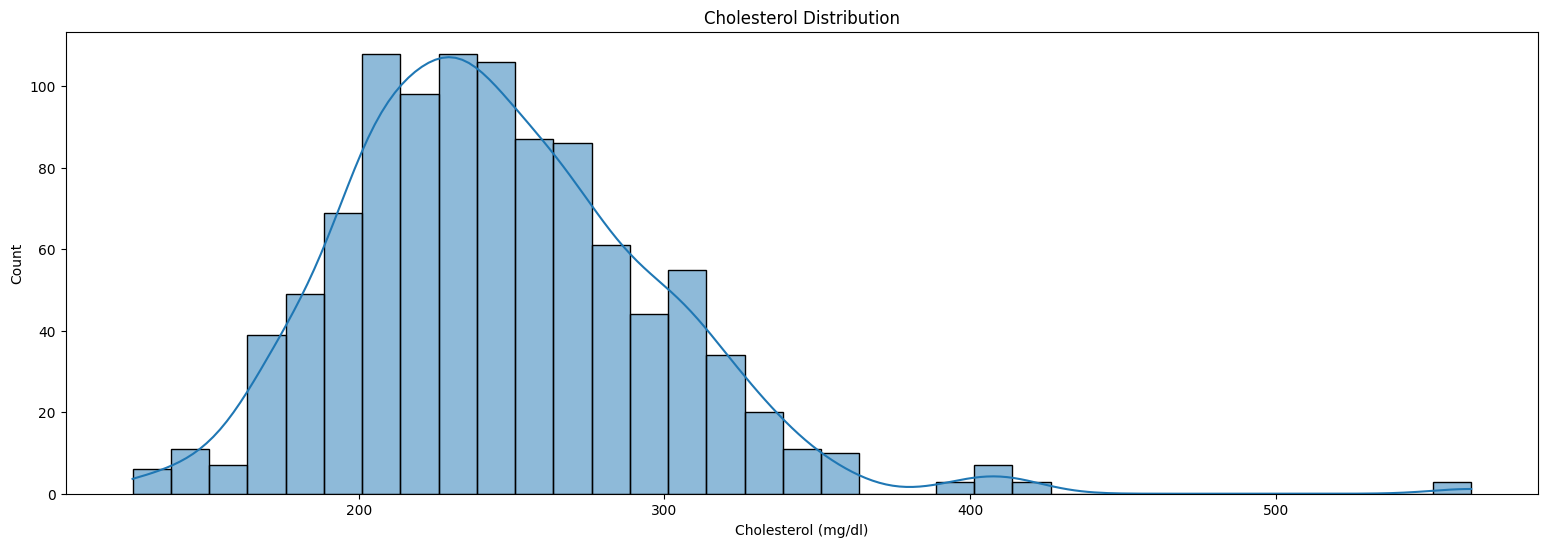

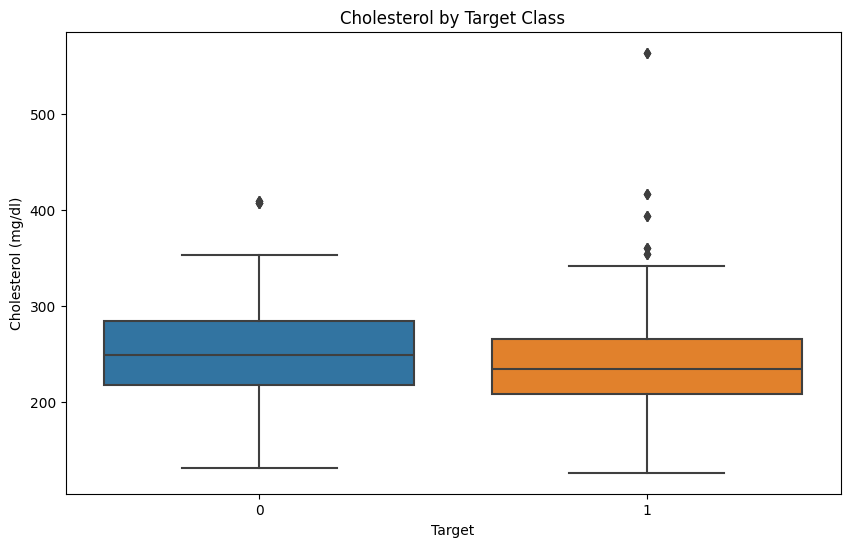

In [ ]:
# Cholesterol Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.histplot(df['chol'], kde=True, ax=ax)
ax.set_title('Cholesterol Distribution')
ax.set_xlabel('Cholesterol (mg/dl)')
ax.set_ylabel('Count')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='target', y='chol', data=df, ax=ax)
ax.set_title('Cholesterol by Target Class')
ax.set_xlabel('Target')
ax.set_ylabel('Cholesterol (mg/dl)')
plt.show()


The histogram shows the cholesterol levels of patients, revealing a bell-shaped distribution that peaks in the middle range and tapers off towards the higher and lower ends. This suggests that most patients have cholesterol levels in a moderate range, with fewer individuals having extremely high or low levels.The box plot compares cholesterol levels between patients with and without heart disease, distinguished by blue and orange colors, respectively. Both categories exhibit a similar interquartile range. Outliers are present in both groups, indicating individuals with significantly high cholesterol levels.

### 2.1.7 Heart Disease by Fasting Blood Sugar


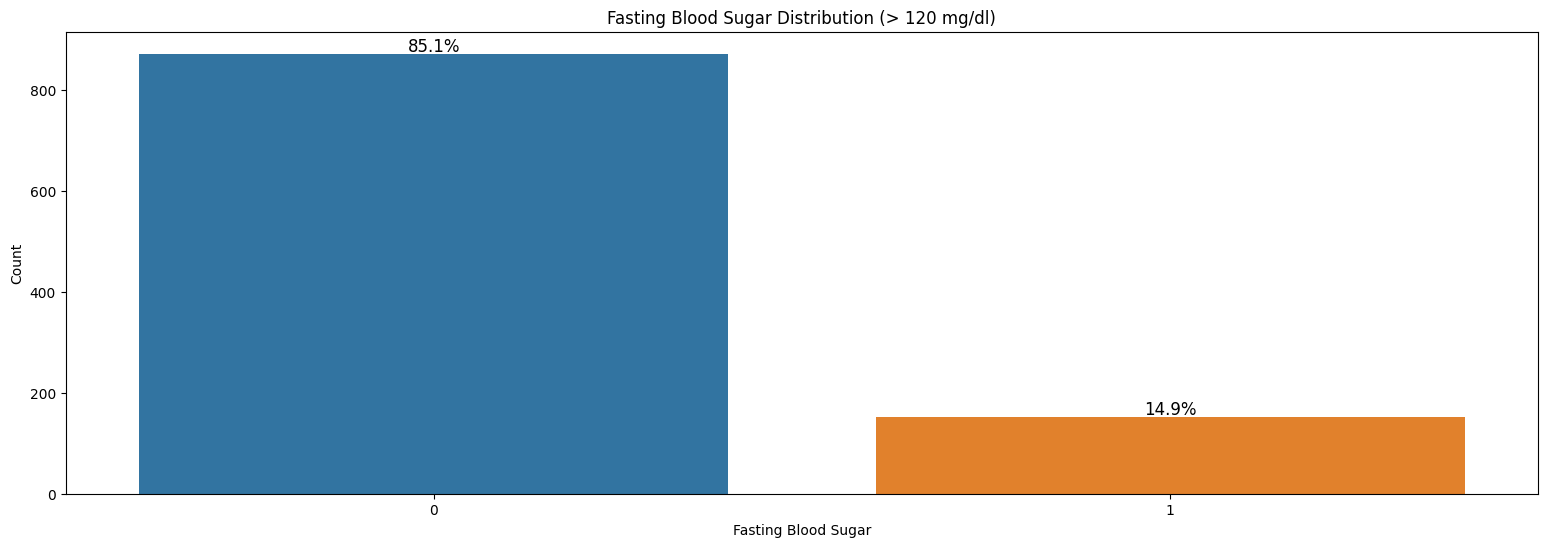

<ipython-input-25-2653d3df115b>:19: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  percentage_by_fbs = df.groupby(['fbs', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)


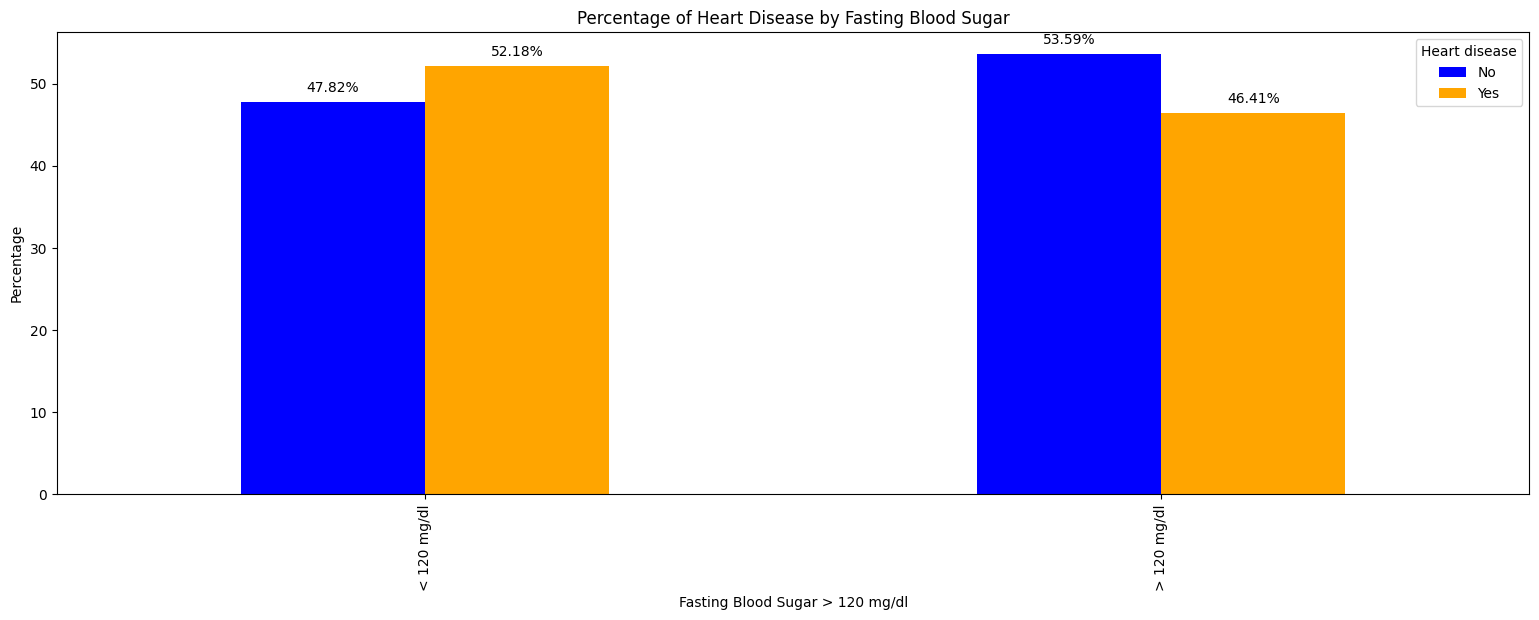

In [ ]:
# Fasting Blood Sugar Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.countplot(x='fbs', data=df, ax=ax)
ax.set_title('Fasting Blood Sugar Distribution (> 120 mg/dl)')
ax.set_xlabel('Fasting Blood Sugar')
ax.set_ylabel('Count')

# Adding percentage annotations
total = len(df['fbs'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

total_by_fbs = df.groupby('fbs')['target'].count()
percentage_by_fbs = df.groupby(['fbs', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)
percentage_by_fbs = percentage_by_fbs.unstack()

# Plot
fig, ax = plt.subplots(figsize=(19, 6))

percentage_by_fbs.plot(kind='bar', ax=ax, color=['blue', 'orange'])
ax.set_xlabel('Fasting Blood Sugar > 120 mg/dl')
ax.set_ylabel('Percentage')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Percentage of Heart Disease by Fasting Blood Sugar')
plt.xticks(ticks=[0, 1], labels=['< 120 mg/dl', '> 120 mg/dl'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()


The first bar chart represents the distribution of fasting blood sugar levels among patients, comparing those with levels below 120 mg/dl and those above. The vast majority have fasting blood sugar levels below 120 mg/dl, denoted by the blue bar, with a smaller portion exceeding this threshold, indicated by the orange bar.The seconf bar chart shows the percentage of patients with and without heart disease relative to their fasting blood sugar levels. There's a nearly even split in the prevalence of heart disease among patients with fasting blood sugar greater than 120 mg/dl, whereas for patients with lower levels, the presence of heart disease is slightly less. The comparison highlights the relationship between fasting blood sugar levels and the occurrence of heart disease within this patient group.







###2.1.8 Heart Disease by Resting Electrocardiographic Results

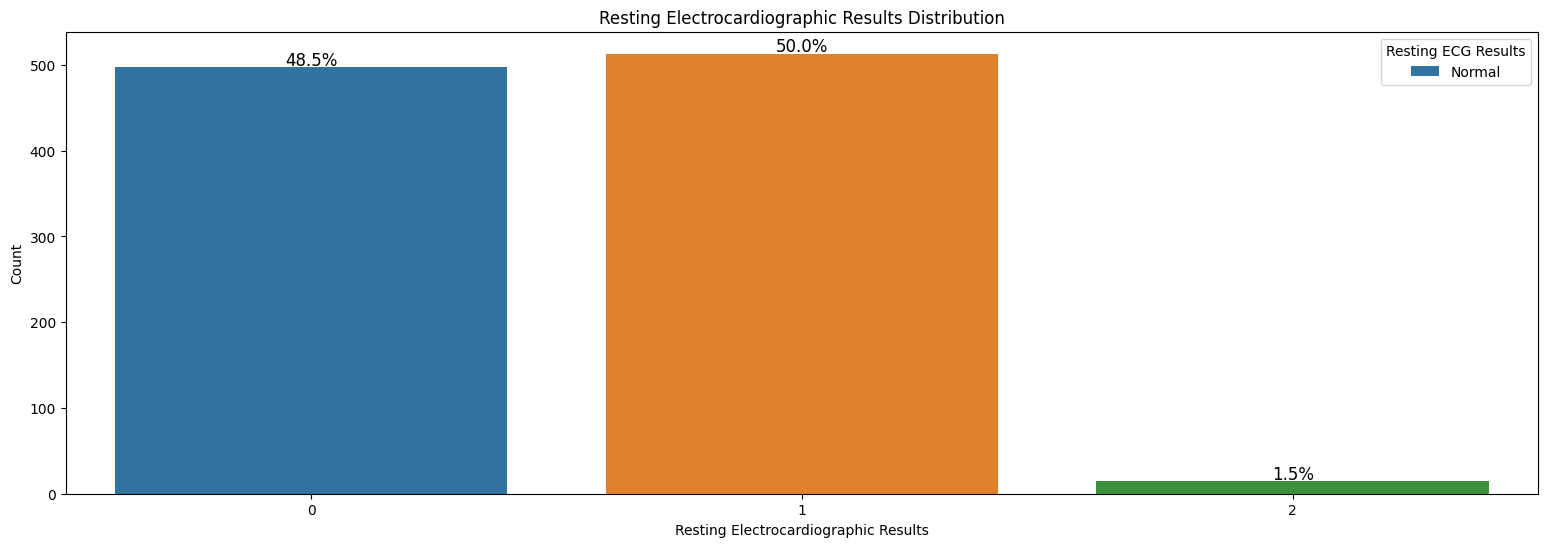

<ipython-input-26-900156ea32b8>:18: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  percentage_by_restecg = df.groupby(['restecg', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)


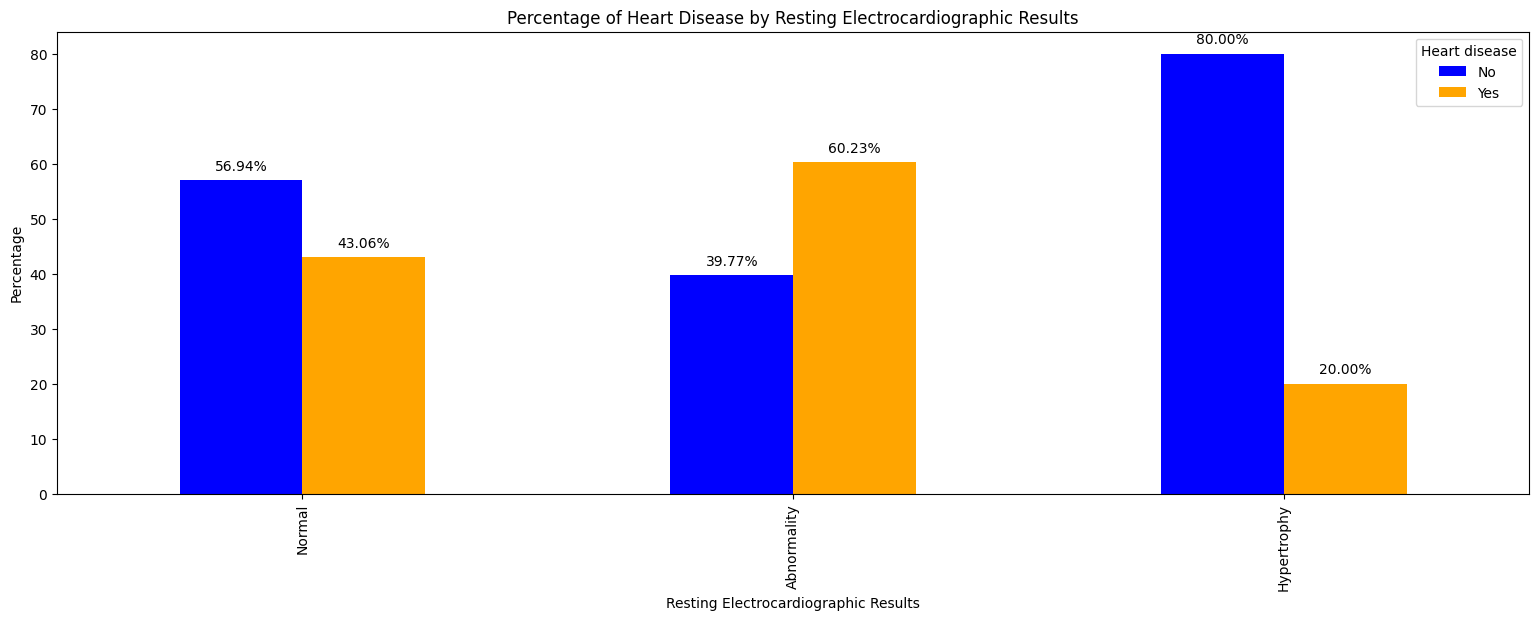

In [ ]:
# Resting Electrocardiographic Results Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.countplot(x='restecg', data=df, ax=ax)
ax.set_title('Resting Electrocardiographic Results Distribution')
ax.set_xlabel('Resting Electrocardiographic Results')
ax.set_ylabel('Count')
total = len(df['restecg'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
restecg_labels = ['Normal', 'ST-T Wave Abnormality', 'Left Ventricular Hypertrophy']
ax.legend(labels=restecg_labels, title='Resting ECG Results', loc='upper right')
plt.show()

total_by_restecg = df.groupby('restecg')['target'].count()
percentage_by_restecg = df.groupby(['restecg', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)
percentage_by_restecg = percentage_by_restecg.unstack()

# Plot
fig, ax = plt.subplots(figsize=(19, 6))

percentage_by_restecg.plot(kind='bar', ax=ax, color=['blue', 'orange'])
ax.set_xlabel('Resting Electrocardiographic Results')
ax.set_ylabel('Percentage')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Percentage of Heart Disease by Resting Electrocardiographic Results')
plt.xticks(ticks=[0, 1, 2], labels=['Normal', 'Abnormality', 'Hypertrophy'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()




The first bar chart showcases the distribution of resting electrocardiographic results among the patients. A significant majority of the patients have a normal result (denoted by 0), while a substantial portion has a result indicating an abnormality (denoted by 1), and only a few show signs of probable left ventricular hypertrophy (denoted by 2).
The second bar chart contrasts the percentage of heart disease occurrence within different categories of resting electrocardiographic results. Patients with normal ECG results have a more balanced distribution of heart disease presence, while those with ECG abnormalities have a higher incidence of heart disease. Notably, the presence of heart disease is least common in patients with left ventricular hypertrophy.

### 2.1.9 Heart Disease by Maximum Heart Rate Achieved

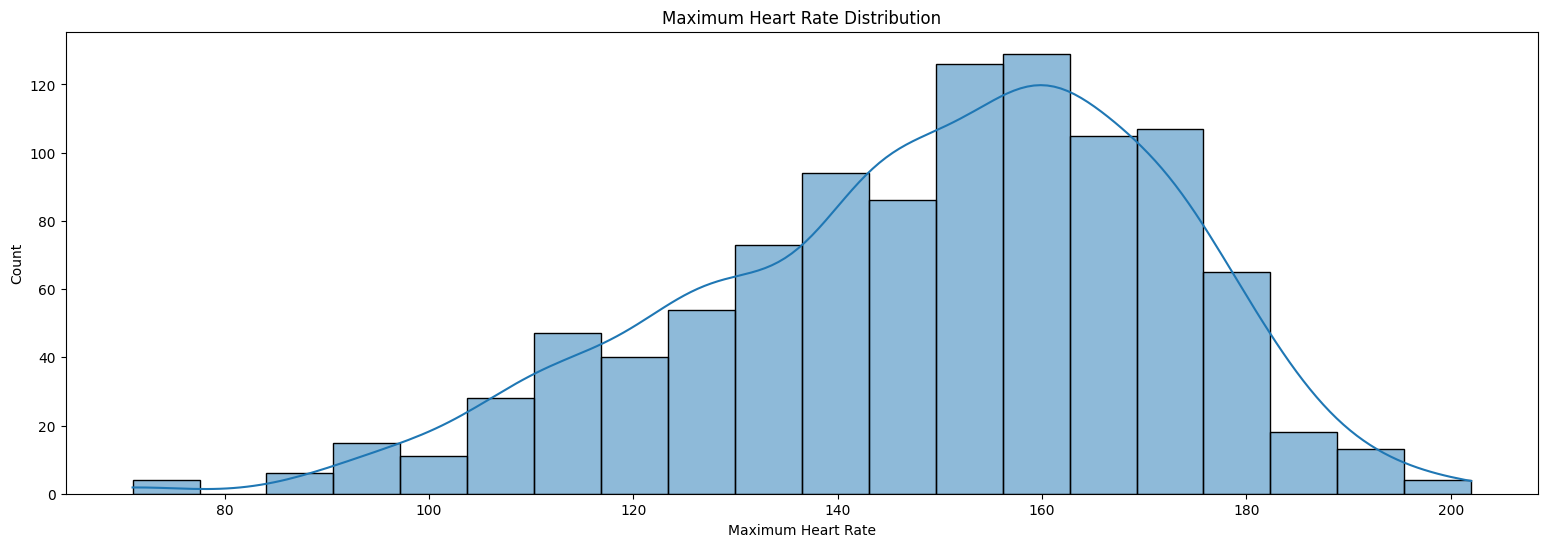

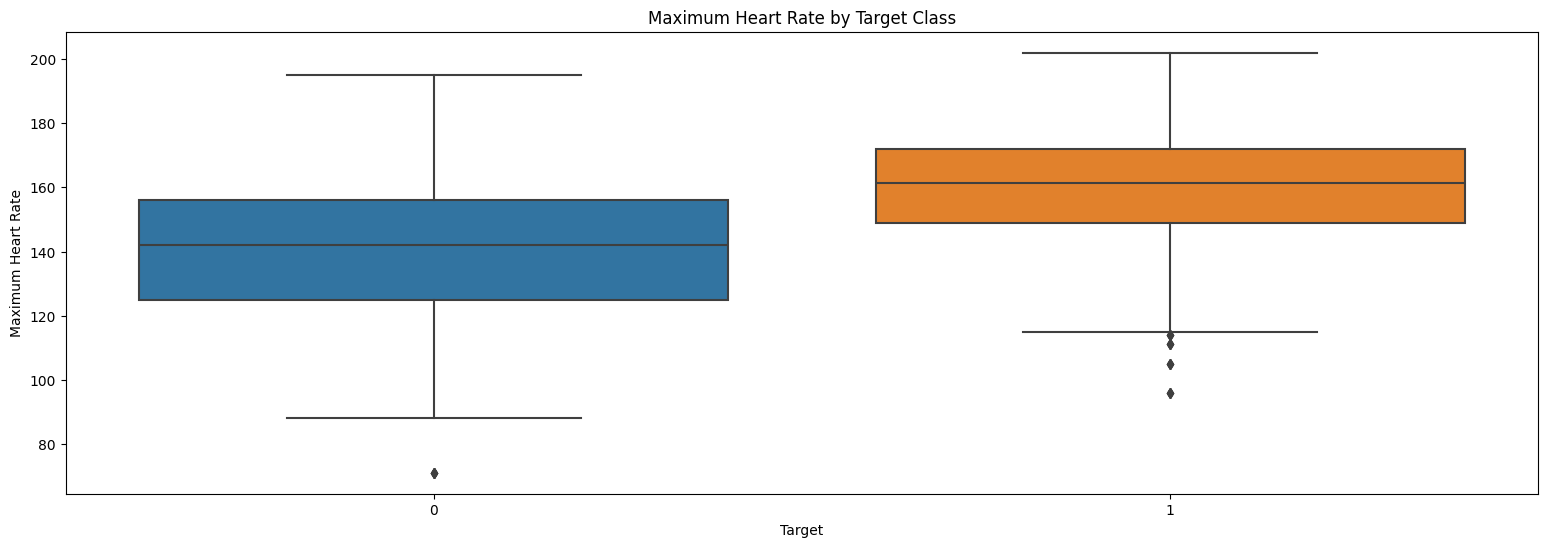

In [ ]:
# Maximum Heart Rate Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.histplot(df['thalach'], kde=True, ax=ax)
ax.set_title('Maximum Heart Rate Distribution')
ax.set_xlabel('Maximum Heart Rate')
ax.set_ylabel('Count')
plt.show()

fig, ax = plt.subplots(figsize=(19, 6))
sns.boxplot(x='target', y='thalach', data=df, ax=ax)
ax.set_title('Maximum Heart Rate by Target Class')
ax.set_xlabel('Target')
ax.set_ylabel('Maximum Heart Rate')
plt.show()


The histogram depicts the distribution of maximum heart rate achieved by patients in the study. The majority of patients achieve a heart rate in the central range of the distribution, with fewer patients reaching very high or very low maximum heart rates. The smooth curve overlaid on the histogram suggests a normal distribution of maximum heart rates among the patients.
The box plot compares the maximum heart rate achieved between patients with no heart disease and those with heart disease. The median heart rate for patients with heart disease is notably higher, and the range of heart rates is broader, as indicated by the spread of the orange box compared to the blue one. Outliers are observed in both categories, showing some individuals with exceptionally high or low maximum heart rates.

###2.1.10 Heart Disease by Exercise Induced Angina

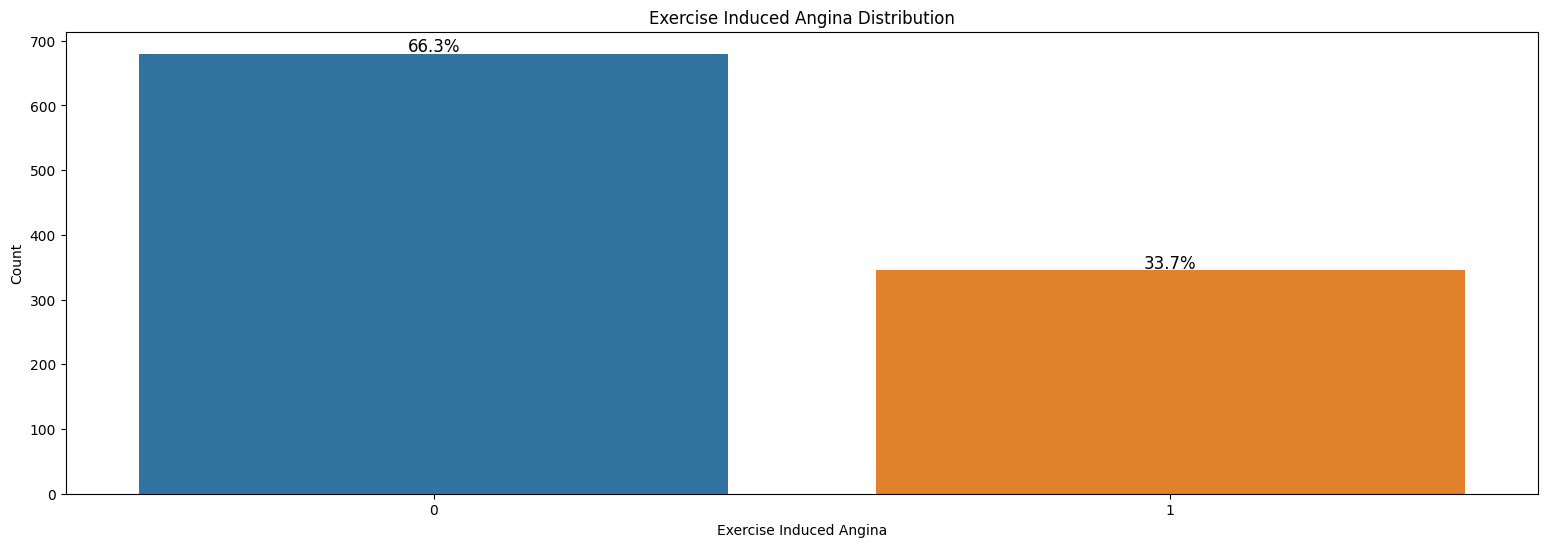

<ipython-input-28-ad278a58e0a7>:19: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  percentage_by_exang = df.groupby(['exang', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)


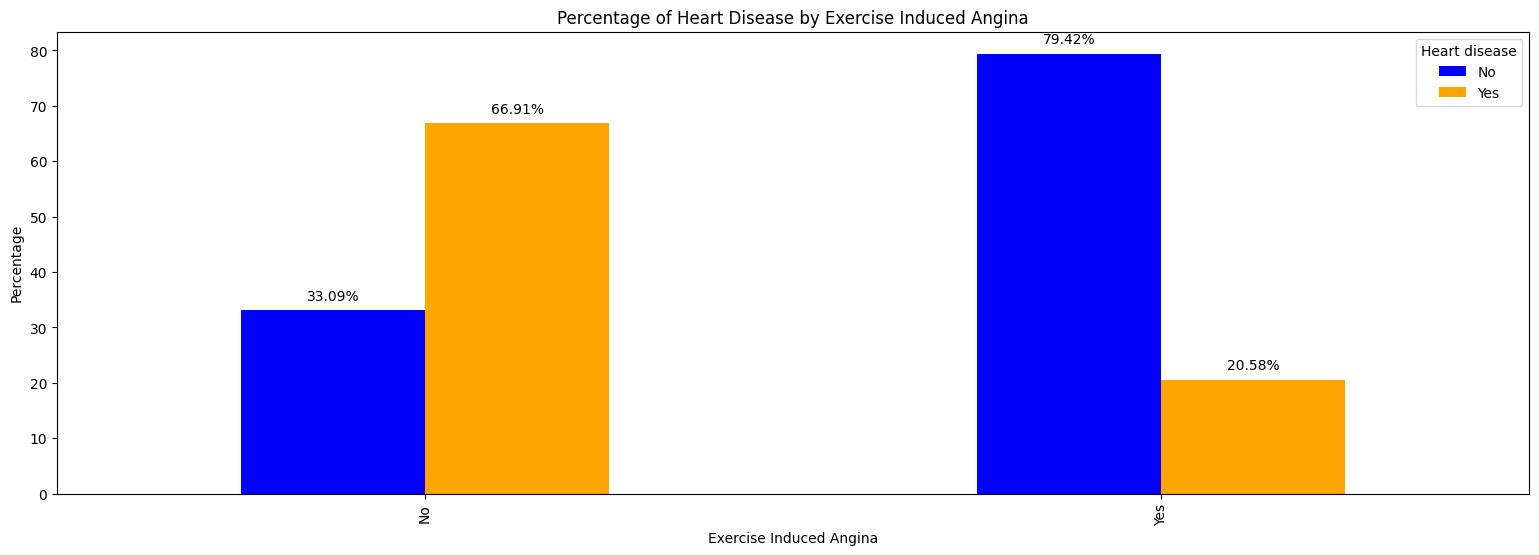

In [ ]:
# Exercise Induced Angina Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.countplot(x='exang', data=df, ax=ax)
ax.set_title('Exercise Induced Angina Distribution')
ax.set_xlabel('Exercise Induced Angina')
ax.set_ylabel('Count')

# Adding percentage annotations
total = len(df['exang'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

total_by_exang = df.groupby('exang')['target'].count()
percentage_by_exang = df.groupby(['exang', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)
percentage_by_exang = percentage_by_exang.unstack()

# Plot
fig, ax = plt.subplots(figsize=(19, 6))

percentage_by_exang.plot(kind='bar', ax=ax, color=['blue', 'orange'])
ax.set_xlabel('Exercise Induced Angina')
ax.set_ylabel('Percentage')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Percentage of Heart Disease by Exercise Induced Angina')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()



The first bar chart shows the distribution of patients based on the presence of exercise-induced angina. A majority of patients do not experience angina during exercise, as indicated by the blue bar. In contrast, the orange bar represents a smaller group of patients who do experience angina when exercising.The second bar chart details the relationship between exercise-induced angina and the prevalence of heart disease. The blue bar indicates a lower occurrence of heart disease in patients who do not experience angina with exercise, while the orange bar reveals a significantly higher rate of heart disease in patients who do report angina during exercise.

###2.1.11 Heart Disease by ST Depression

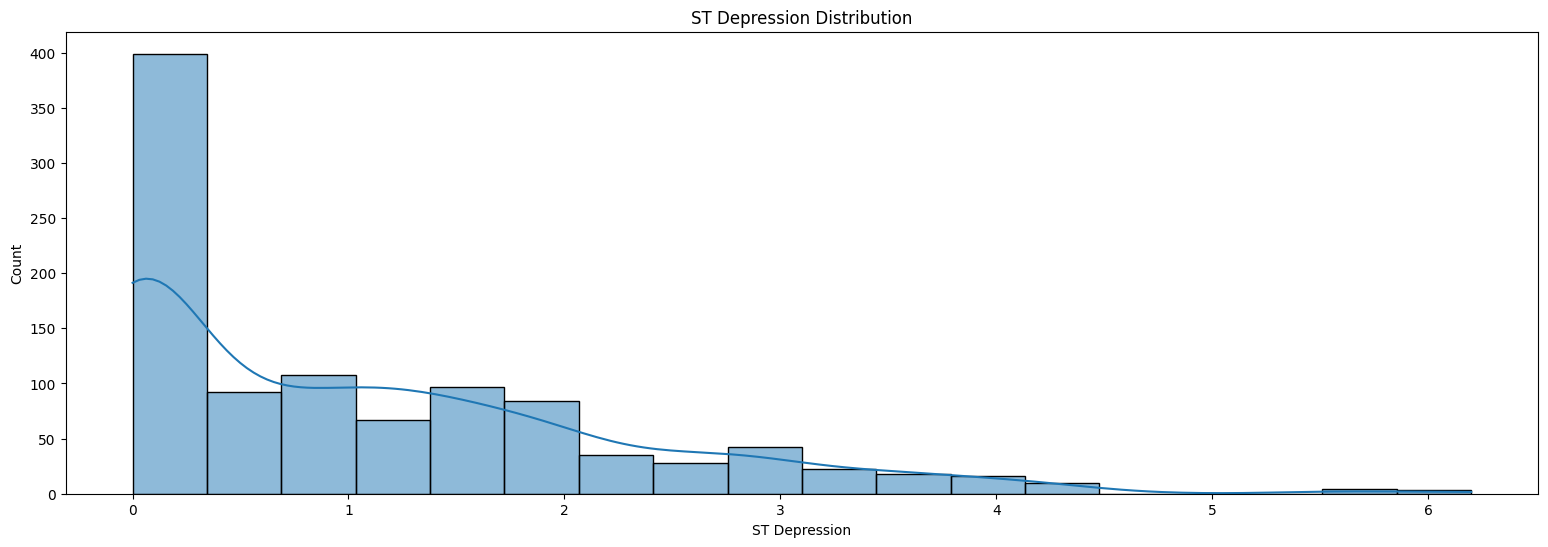

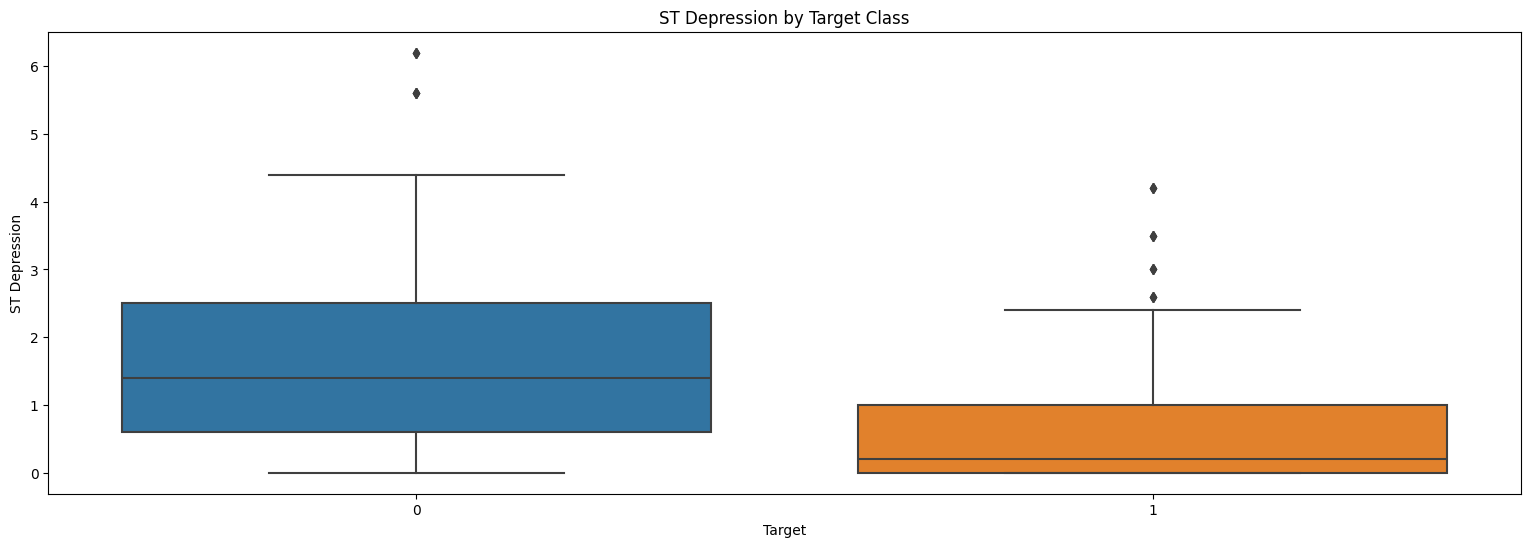

In [ ]:
# ST Depression Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.histplot(df['oldpeak'], kde=True, ax=ax)
ax.set_title('ST Depression Distribution')
ax.set_xlabel('ST Depression')
ax.set_ylabel('Count')
plt.show()

fig, ax = plt.subplots(figsize=(19, 6))
sns.boxplot(x='target', y='oldpeak', data=df, ax=ax)
ax.set_title('ST Depression by Target Class')
ax.set_xlabel('Target')
ax.set_ylabel('ST Depression')
plt.show()


The histogram depicts the frequency of ST depression values measured in the patients, showing a skew towards lower values with the highest count at zero depression. The number of patients decreases as the level of ST depression increases, indicating that most patients do not exhibit significant ST depression during exercise relative to rest.The box plot compares ST depression levels between patients without heart disease and those with heart disease. The median ST depression is higher in patients without heart disease, and the spread of the data is wider, suggesting a greater variation in ST depression levels among these patients. Outliers are present in both categories, particularly in the group with heart disease.

###2.1.12 Heart Disease by Slope of the Peak Exercise ST Segment

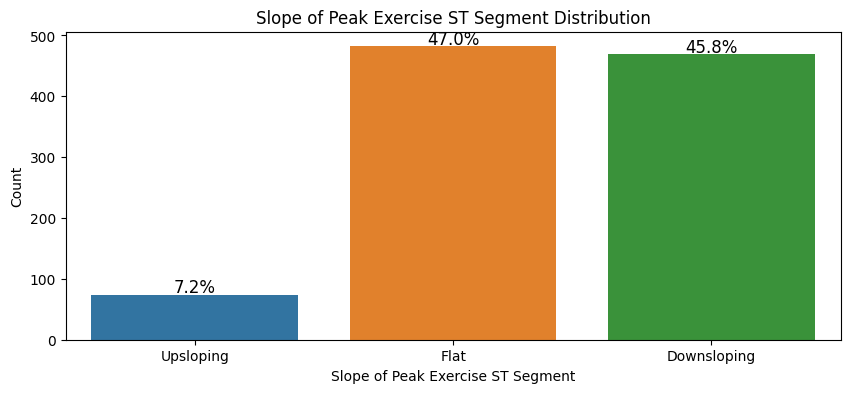

<ipython-input-30-02cab38b3ac7>:19: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  percentage_by_slope = df.groupby(['slope', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)


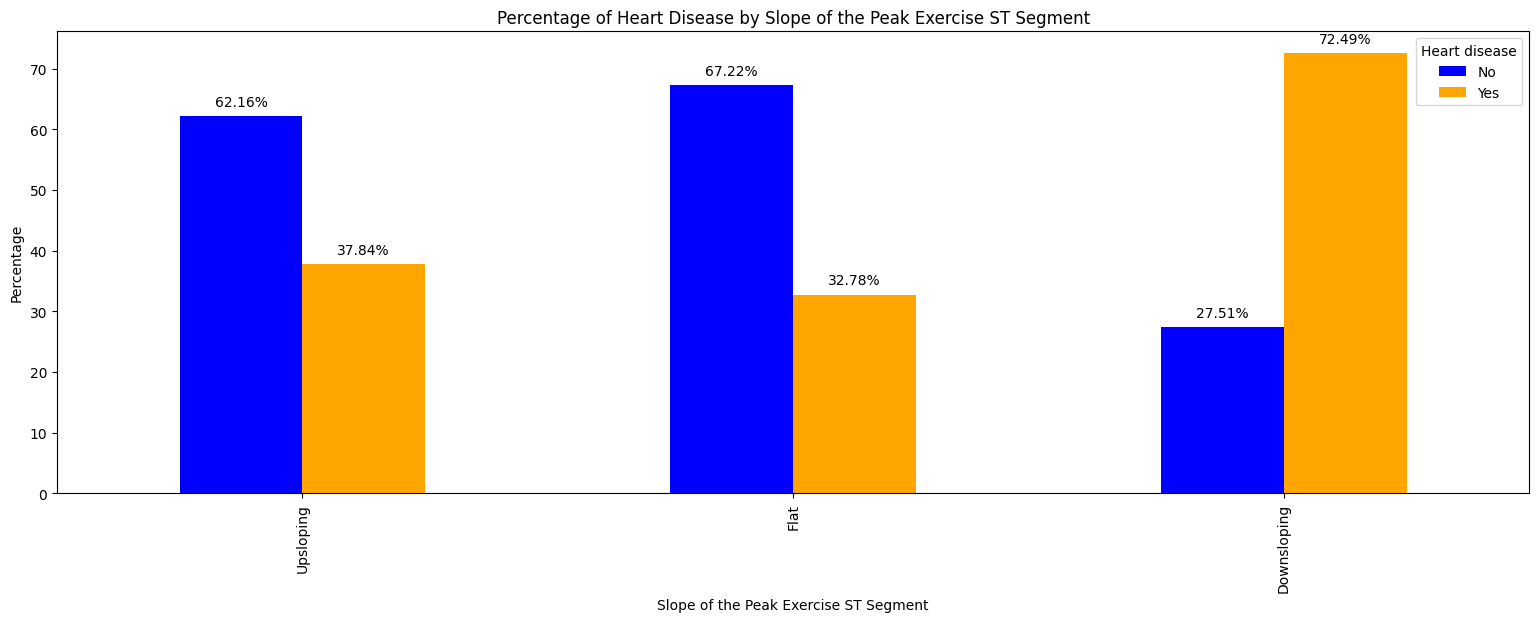

In [ ]:
# Slope Analysis
fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(x='slope', data=df, ax=ax)
ax.set_title('Slope of Peak Exercise ST Segment Distribution')
ax.set_xlabel('Slope of Peak Exercise ST Segment')
ax.set_ylabel('Count')

total = len(df['slope'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(ticks=[0, 1,2], labels=['Upsloping', 'Flat', 'Downsloping'])
plt.show()

total_by_slope = df.groupby('slope')['target'].count()
percentage_by_slope = df.groupby(['slope', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)
percentage_by_slope = percentage_by_slope.unstack()

# Plot
fig, ax = plt.subplots(figsize=(19, 6))

percentage_by_slope.plot(kind='bar', ax=ax, color=['blue', 'orange'])
ax.set_xlabel('Slope of the Peak Exercise ST Segment')
ax.set_ylabel('Percentage')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Percentage of Heart Disease by Slope of the Peak Exercise ST Segment')
plt.xticks(ticks=[0, 1, 2], labels=['Upsloping', 'Flat', 'Downsloping'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()



The first bar chart shows the frequency of different slopes of the peak exercise ST segment among patients. The slope '1', indicating a flat ST segment, is the most common, followed by the '2', which represents an downsloping ST segment. The '0' category, indicative of a upsloping ST segment, is the least frequent.The second bar chart compares the percentage of heart disease incidence across the different types of ST segment slopes during peak exercise. A higher percentage of heart disease is observed in patients with a downsloping slope, while those with an flat ST segment show a lower percentage of heart disease. The trend suggests that the nature of the ST segment slope may be associated with the presence of heart disease.

###2.1.13 Heart Disease by Number of Major Vessels Coloured by Fluroscopy

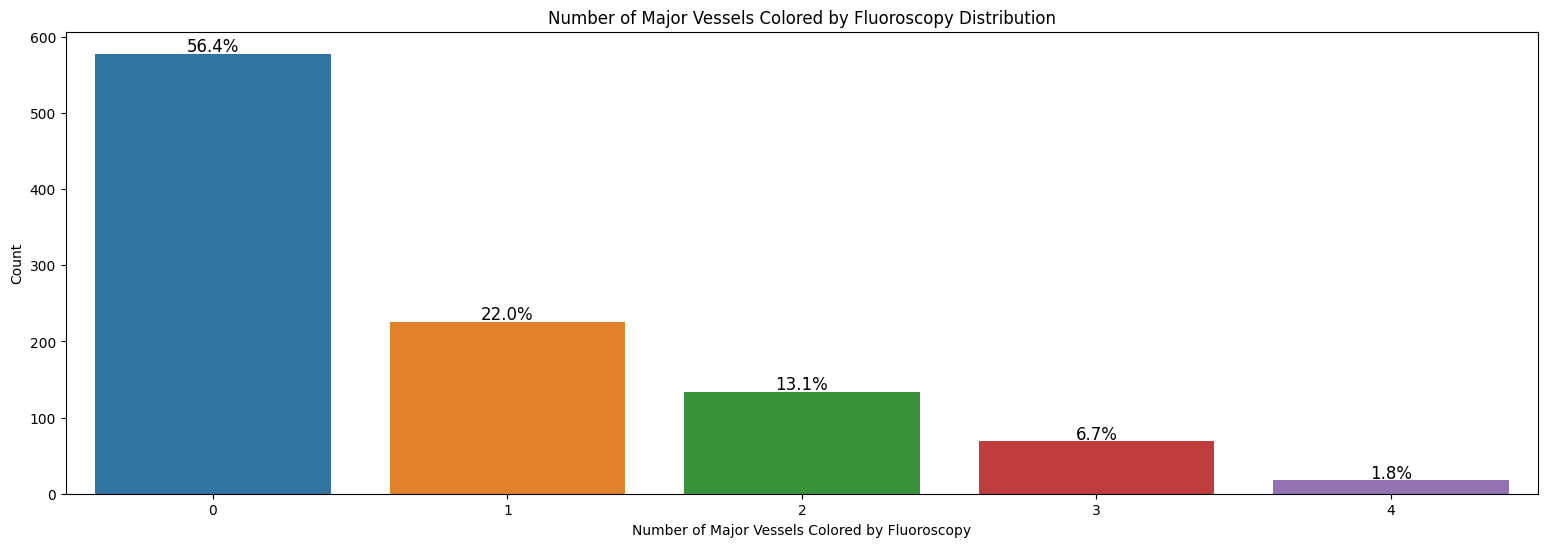

<ipython-input-31-93900398e698>:19: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  percentage_by_ca = df.groupby(['ca', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)


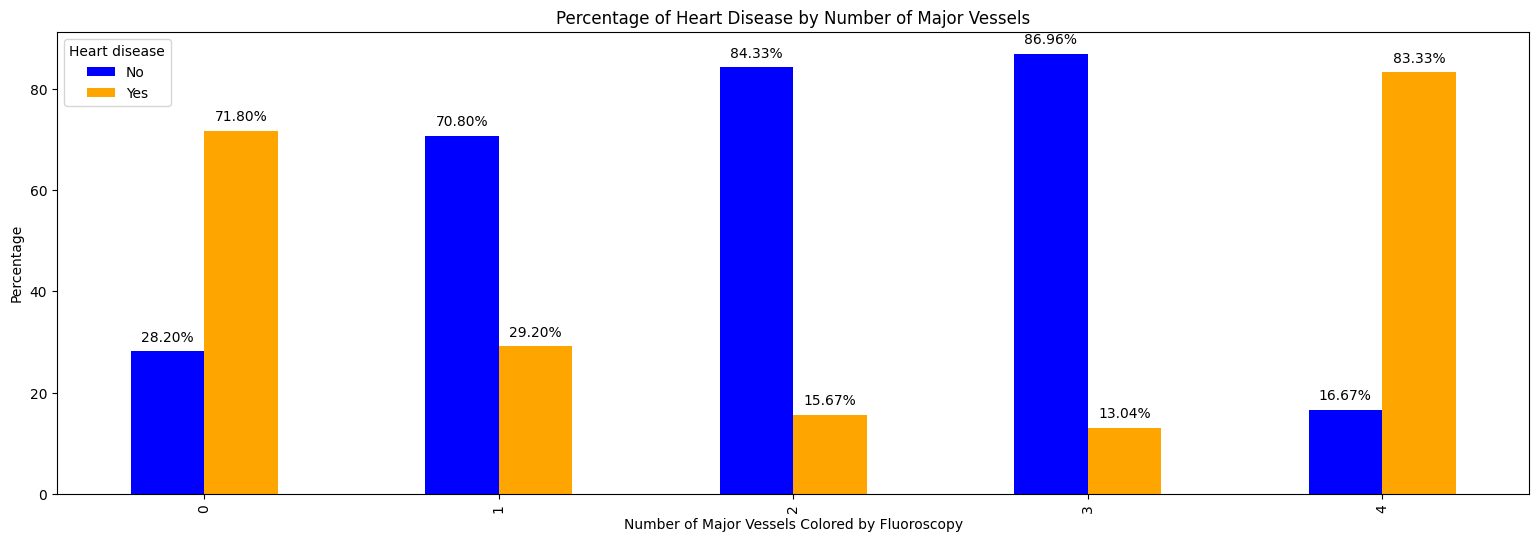

In [ ]:
# Number of Major Vessels Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.countplot(x='ca', data=df, ax=ax)
ax.set_title('Number of Major Vessels Colored by Fluoroscopy Distribution')
ax.set_xlabel('Number of Major Vessels Colored by Fluoroscopy')
ax.set_ylabel('Count')

# Adding percentage annotations
total = len(df['ca'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

total_by_ca = df.groupby('ca')['target'].count()
percentage_by_ca = df.groupby(['ca', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)
percentage_by_ca = percentage_by_ca.unstack()

# Plot
fig, ax = plt.subplots(figsize=(19, 6))

percentage_by_ca.plot(kind='bar', ax=ax, color=['blue', 'orange', 'green', 'red'])
ax.set_xlabel('Number of Major Vessels Colored by Fluoroscopy')
ax.set_ylabel('Percentage')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Percentage of Heart Disease by Number of Major Vessels')
plt.xticks(ticks=range(len(percentage_by_ca.index)), labels=percentage_by_ca.index)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()



The first bar chart visualizes the distribution of the number of major vessels colored by fluoroscopy observed in patients. Most patients have no major vessels colored  with progressively fewer patients as the number of colored vessels increases. The smallest group is those with four colored vessels.
The second bar chart depicts the percentage of heart disease by the number of major vessels colored by fluoroscopy. It  prevalence of heart disease as the number of colored vessels fluctuates, with the highest percentage seen in four colored vessels, more medical related evidence might be required to suggest a correlation between the number of colored vessels and the presence of heart disease.







###2.1.14 Heart Disease by Thalassemia


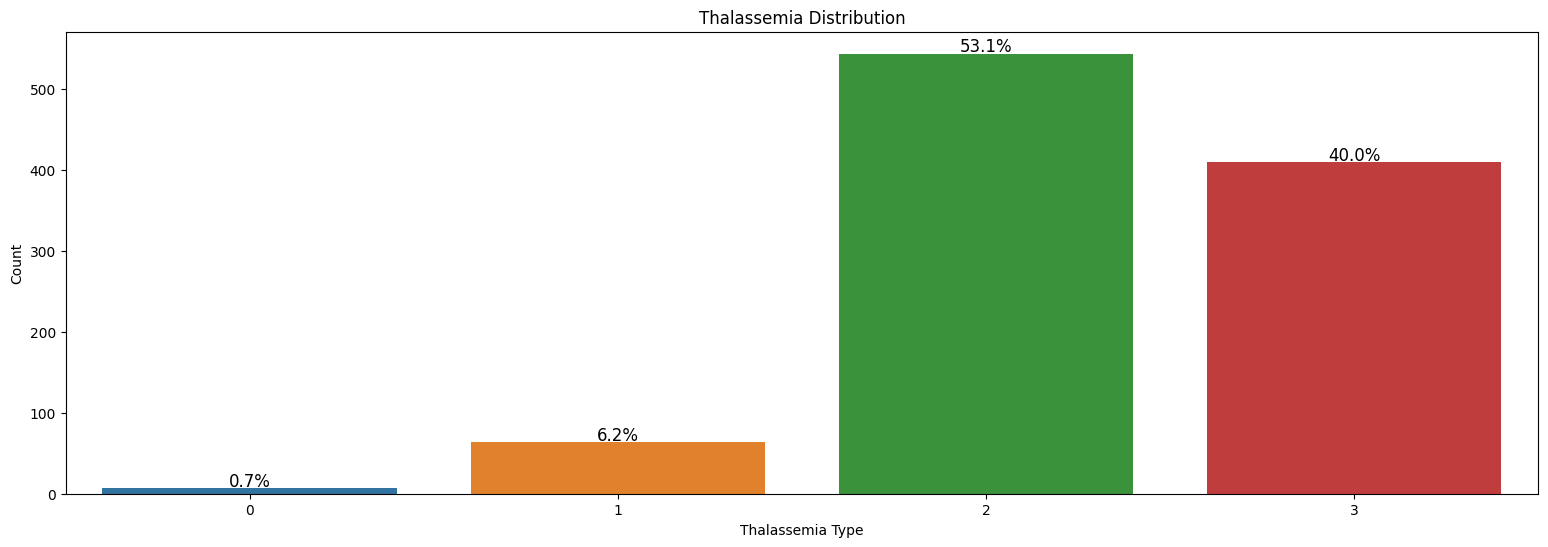

In [ ]:
# Thalassemia Analysis
fig, ax = plt.subplots(figsize=(19, 6))
sns.countplot(x='thal', data=df, ax=ax)
ax.set_title('Thalassemia Distribution')
ax.set_xlabel('Thalassemia Type')
ax.set_ylabel('Count')

# Adding percentage annotations
total = len(df['thal'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')



<ipython-input-33-636dd1b61a16>:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  percentage_by_thal = df.groupby(['thal', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)


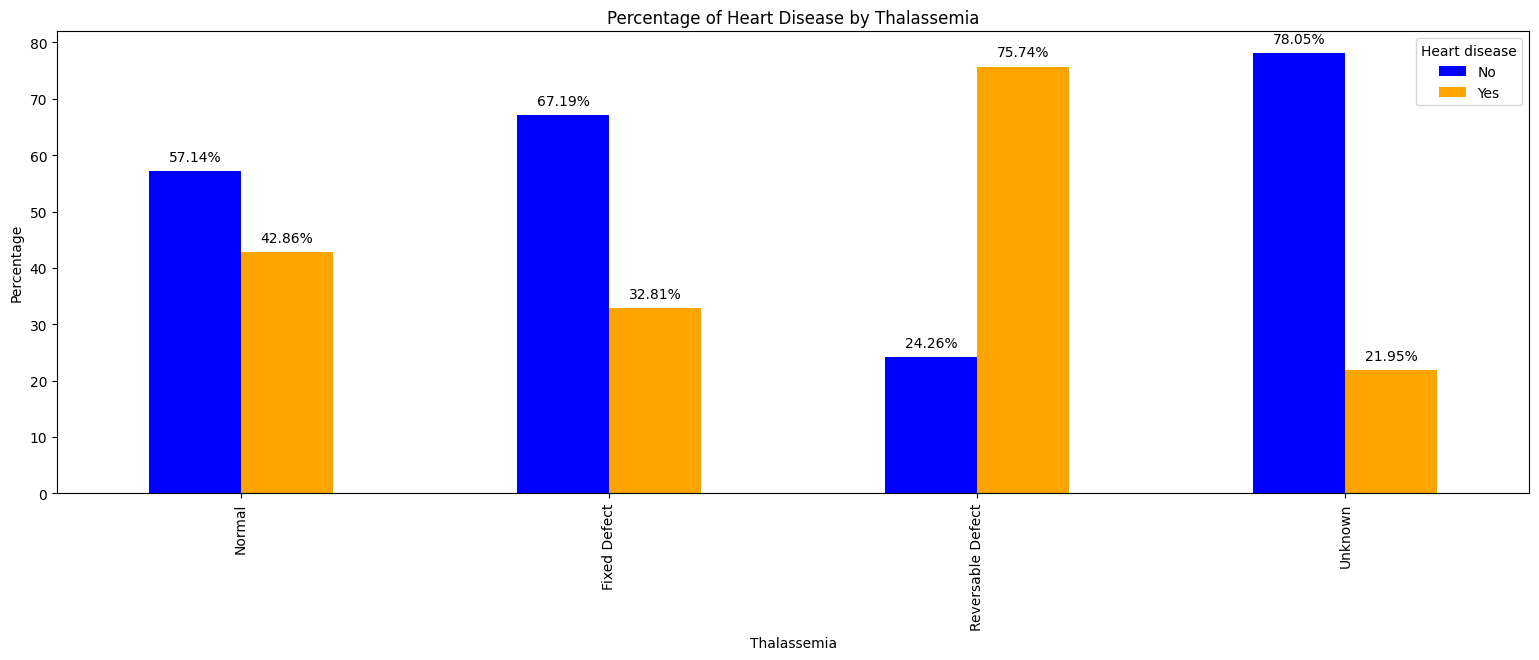

In [ ]:
total_by_thal = df.groupby('thal')['target'].count()
percentage_by_thal = df.groupby(['thal', 'target']).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)
percentage_by_thal = percentage_by_thal.unstack()

# Plot
fig, ax = plt.subplots(figsize=(19, 6))

percentage_by_thal.plot(kind='bar', ax=ax, color=['blue', 'orange', 'green','yellow'])
ax.set_xlabel('Thalassemia')
ax.set_ylabel('Percentage')
ax.legend(title='Heart disease', labels=['No', 'Yes'])
ax.set_title('Percentage of Heart Disease by Thalassemia')
plt.xticks(ticks=range(len(percentage_by_thal.index)), labels=['Normal', 'Fixed Defect', 'Reversable Defect','Unknown'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()


The first bar chart presents the distribution of thalassemia types among patients. The most common type observed is '2', indicating a reversible defect, followed by '3', an unknown type, and '1', a fixed defect. The '0' category, representing normal thalassemia results, has the fewest occurrences.
The second bar chart correlates the types of thalassemia with the presence of heart disease. Patients with a reversible defect thalassemia type have a highest percentage of heart disease compared to others. The data suggests that the type of thalassemia might be linked to the likelihood of having heart disease.

#2.2 Summary for Data Understanding & EDA

The data understanding and Exploratory Data Analysis (EDA) stage of this project provided valuable insights into the heart disease data set. The analysis included a detailed examination of correlations between various medical parameters and the relationship between them and heart disease. The correlation matrix and scatter plots reveal some variables, such as the type of chest pain and maximum heart rate, as important indicators. Distributions of key attributes highlights age and gender as influencing factors in disease epidemic.

From EDA, female with age of 50-59 present higher percentage of getting heart disease. besides, it also bring out that chest pain, fasting blood sugar greater than 120 mg/dl, abnormal ECG while hypertrophy ECG present least heart disease, maximum heart rate in 160 (median) having higher percentage, downsloping slope of the peak exercise ST segment.

These findings support the subsequent model development, emphasizing the importance of these forecasting factors, and providing a solid foundation for creating accurate and reliable forecasting models.

# **3. Modeling Selection**
In the project, four different machine learning models were selected to predict heart disease based on a range of clinical parameters. These models, chosen for their diverse approaches in handling classification tasks, included Random Forest, Logistic Regression, Decision Tree, and Support Vector Machine (SVM). Each model was applied to capture different patterns in the data.

### Splitting the Dataset into train and test set
Dataset will be split into 80/20 split

In [ ]:
# Splitting the data

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


### 3.1 Random Forest Model

In [ ]:
# Random Forest model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)


RandomForestClassifier()

In [ ]:
# Making predictions
y_pred = rf_model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

[[102   0]
 [  3 100]]


###3.2 Logistic Regression Model

In [ ]:
# Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
# Making predictions
y_pred = log_reg.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7951219512195122
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205

[[73 29]
 [13 90]]


### 3.3 Decision Tree

In [ ]:
X = df.drop(['target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Making predictions
y_pred = dt_model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

[[102   0]
 [  3 100]]


### 3.4 Support Vector Machine (SVM)

In [ ]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

# Making predictions
y_pred = svm_model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.6829268292682927
              precision    recall  f1-score   support

           0       0.71      0.61      0.66       102
           1       0.66      0.76      0.71       103

    accuracy                           0.68       205
   macro avg       0.69      0.68      0.68       205
weighted avg       0.69      0.68      0.68       205

[[62 40]
 [25 78]]


# **4. Model Evaluation**

Based on the performance metrics from the machine learning models presented, the Random Forest and Decision Tree models have the highest accuracy, both scoring around 98.5%. This is a remarkably high figure and suggests that both models are highly effective at predicting heart disease in the given dataset. The Logistic Regression model shows a reasonable accuracy at around 79.5%, which is significantly lower than the other two. The SVM model has the lowest accuracy, at approximately 68.3%.

When determining the optimal model for our classification, we considered several factors beyond just accuracy. Overfitting is a common problem with highly accurate models on the training data, which may not generalize well to unseen data. The Random Forest model, which is an ensemble method, tends to handle overfitting better than a single Decision Tree by averaging multiple trees. This makes it more robust to noise and capable of generalizing better.

We also assess the confusion matrix.The confusion matrix is a valuable tool for assessing the performance of classification models, providing insight into not only the correct predictions but also the types of errors made by the model.
For the Random Forest and Decision Tree models, the confusion matrices show an almost perfect classification with very few misclassifications. Both models have only 3 false negatives (where the model predicted 'no disease' when there was disease) and no false positives (where the model predicted 'disease' when there was none). This indicates an excellent sensitivity or true positive rate, meaning the models are highly capable of identifying patients with the disease.

The Logistic Regression model has a higher number of false negatives (29) and false positives (13), indicating that while it has a decent balance of sensitivity and specificity, it is more prone to misclassification than the Random Forest and Decision Tree models.

The SVM model shows the highest number of false negatives (40) and false positives (25), suggesting that this model has the lowest sensitivity and specificity among the four models. It is the least reliable in distinguishing between the presence and absence of heart disease in patients.


In conclusion, the Random Forest and Decision Tree models not only show high accuracy but also demonstrate a high degree of reliability in their predictions, as evidenced by their confusion matrices. The low number of false negatives is especially important in medical diagnoses, as it means the model is less likely to miss cases of disease. However, it is essential to ensure these models are not overfitted and can generalize to new, unseen data before they can be considered truly superior. These two models strike a balance between high accuracy and the ability to generalize, making it a robust choice for predicting heart disease. Nevertheless, it would be prudent to validate these results with cross-validation and on an independent test set to ensure the model's performance is consistent and reliable before clinical deployment.

# **5. Deployment**


####**"CardioAssist"- Heart Disease Risk Assessment Tool**
"CardioAssist" will be a user-friendly digital tool designed to assist healthcare professionals and patients in swiftly assessing the risk of heart disease. It will utilize a sophisticated algorithm and 14 essential medical indicators. Set to be integrated seamlessly into electronic health record systems, it will simplify the process for doctors and healthcare providers. Additionally, "CardioAssist" will offer educational resources about heart health, aiming to equip patients with the knowledge they need to understand and manage their cardiovascular risk proactively. This tool will not only aid in accurate diagnosis but also empower patients with vital information about heart disease.

### 5.1 Continuous Monitoring and Updates
Post-deployment, "CardioAssist" will undergo continuous monitoring for performance and accuracy. It will be updated periodically with the latest medical research and guidelines in cardiology, ensuring that the risk assessments remain relevant and accurate.

### 5.2 Feedback Mechanism for Improvement
A feedback system will be established for both healthcare professionals and patients to provide insights into the usability and effectiveness of "CardioAssist". This feedback will be crucial for ongoing refinement and enhancement of the tool.

# **6. Risk Assessment and reproducible reseach plan**

### 6.1 Generalization to diverse population
Dataset sources including geographic regions and healthcare facilities which it is potentially present bias on the popultaion. the sample data may not be representative of entire population.

### 6.2 Data source variability
Dataset was collected with multiple sources and location, it is consist and combined with 4 dataset which potentially in data source variability and introduce biases or confounding variables.

### 6.3 Dynamic document generationa and version control
Dynamic document generation integrates these steps, transforming code into an integral part of the manuscript. This approach allows interested readers to gain a better understanding of the contents. Dedicated integrated software development such as Rstudio, Eclipse or VS Code helps the code writing process of comments and provide plugins to generate documentation in PDF or HTML format. In our project, google colab is ultilized which enable the reproducible and user-friendly creation by consolidating code, visualization, modeling and stucture by single document.


### 6.4 Data management planning with accountability and transparency
Documenting the methods and origin of data collected and stored during the research period is crucial and should be formally outlined in a Data Management Plan (DMP). This plan, submitted as part of a grant application, provides a detailed strategy for managing research data throughout the entire research cycle. Platforms like OSF offer built-in tools for version control, allowing researchers to create a workspace aligned with their data management plan. In our project, dataset was extracted from Kaggle which openly accessible by anyone.


# **7. Conclusion**

The heart disease prediction model's data analysis is completed using the CRISP-DM process model. This project starts with business understanding, which shows that heart disease continues to be critical in global health. After stages of data preprocessing exported a list of valuable attributes, we continue with exploratory data analysis (EDA). EDA tells us that females between 50 and 59 have the highest chances of getting heart disease through visualization of the relationship between each attribute. With all the exploratory information, we can proceed with model selection and evaluation. The random forest model is the state-of-the-art model able to predict heart disease at an accuracy of 98.5%.

At the end of the project, we can conclude that the Random Forest model is the best suitable model to be selected. And the model can deployed to production usage to continuously monitor the model's performance. With more real-life production data added to the train model, the model can better predict the heart disease. Future researchers can continue researching new attributes to add into the model to helps in heart disease prediction.